In [18]:
import sys
import os

# Add the src directory to the Python path
sys.path.append(os.path.abspath("../"))
# KMP_DUPLICATE_LIB_OK=TRUE

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [19]:
import torch
from omegaconf import OmegaConf
from src.vae_model import VAESmall, VAEMedium, VAELarge, BetaVAE, VAEPlus
import numpy as np
from tqdm import tqdm

def load_model_and_cfg(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location="cpu")
    cfg = OmegaConf.create(checkpoint["config"])
    cfg.data.train_path = "D:/BBBC021/BBBC021_dataset_cleaned_maxnorm_68.h5"
    cfg.data.metadata_path = "../data/raw/metadata_dataset.h5"

    # Initialize model based on configuration
    name = cfg.model.name
    if name in ("VAESmall"):
        model = VAESmall(cfg.model.input_channels, cfg.model.latent_dim)
    elif name in ("VAEMedium"):
        model = VAEMedium(cfg.model.input_channels, cfg.model.latent_dim)
    elif name in ("VAELarge"):
        model = VAELarge(cfg.model.input_channels, cfg.model.latent_dim)
    elif name in ("Beta_VAE"):
        model = BetaVAE(cfg.model.input_channels, cfg.model.latent_dim, cfg.model.beta)
    elif name in ("VAE+"):
        model = VAEPlus(cfg.model.input_channels, cfg.model.latent_dim, cfg.model.beta, cfg.model.adv_schedule_slope)

    # Load model state dict
    model.cfg = cfg
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

# MODEL SIZE

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "../experiments/models"

modelSmall = load_model_and_cfg(model_path + "/VAESmall/small.pth")
modelMedium = load_model_and_cfg(model_path + "/VAEMedium/medium.pth")
modelLarge = load_model_and_cfg(model_path + "/VAELarge/large.pth")

modelSmall.to(device)
modelMedium.to(device)
modelLarge.to(device)

In [4]:
from src.data_loading_well import load_data_by_well
cfg = modelSmall.cfg
val_loader = load_data_by_well(cfg, split="val")

Total wells Train: 770, Val: 96, Test: 96
Total images in val: 48891 (10.17% of total)


# Reconstruction

## MODEL SIZE

In [5]:
# (Re‐use the approach from before to get per-image errors in batches.)
# Suppose this function exists:
def all_test_reconstruction_errors(model, test_loader, device):
    model.eval()
    model.to(device)

    errors_list = []
    with torch.no_grad():
        for x_batch, _ in tqdm(test_loader, desc=f"Computing reconstruction errors for {model.cfg.model.name}"):
            x_batch = x_batch.to(device)

            mu, logvar = model.encode(x_batch)
            # reparameterization trick
            z = model.reparameterize(mu, logvar)
            recon = model.decode(z)

            # Compute per-image reconstruction loss manually
            squared_diff = ((recon - x_batch) ** 2).view(x_batch.size(0), -1).sum(dim=1)  # (B,)
            mse_term = 0.5 * squared_diff
            D = x_batch[0].numel()
            const = 0.5 * D * np.log(2 * np.pi)
            per_image_loss = mse_term + const  # shape: (B,)

            errors_list.append(per_image_loss.cpu().numpy())

    # Concatenate into one big (N_test,) tensor
    all_errors = np.concatenate(errors_list, axis=0)
    return all_errors

In [6]:
errorsSmall = all_test_reconstruction_errors(modelSmall, val_loader, device)  # shape = (N_test,)
errorsMedium = all_test_reconstruction_errors(modelMedium, val_loader, device)  # shape = (N_test,)
errorsLarge = all_test_reconstruction_errors(modelLarge, val_loader, device)  # shape = (N_test,)

Computing reconstruction errors for VAESmall:   0%|          | 0/191 [00:00<?, ?it/s]

Computing reconstruction errors for VAELarge: 100%|██████████| 191/191 [00:07<00:00, 25.72it/s]


In [8]:
# mean reconstruction error of each model
mean_error_small = np.mean(errorsSmall)
mean_error_medium = np.mean(errorsMedium)
mean_error_large = np.mean(errorsLarge)

print(f"Mean reconstruction error for VAESmall: {mean_error_small:.4f}")
print(f"Mean reconstruction error for VAEMedium: {mean_error_medium:.4f}")
print(f"Mean reconstruction error for VAELarge: {mean_error_large:.4f}")

Mean reconstruction error for VAESmall: 12802.6445
Mean reconstruction error for VAEMedium: 12801.1309
Mean reconstruction error for VAELarge: 12800.0156


In [9]:
import numpy as np
from scipy import stats

# 1) Compute pairwise difference‐vectors:
D_SM = errorsSmall - errorsMedium  # shape = (N_test,)
D_SL = errorsSmall - errorsLarge  # shape = (N_test,)
D_ML = errorsMedium - errorsLarge  # shape = (N_test,)

# 2) Run Shapiro-Wilk on each difference:
def check_normality(vec, label):
    W, pval = stats.shapiro(vec)
    print(f"Shapiro-Wilk for {label}: W = {W:.4f}, p = {pval:.4f}")
    if pval < 0.05:
        print(f"  → Distribution of {label} is likely NOT normal (p < 0.05).")
    else:
        print(f"  → No evidence to reject normality for {label} (p ≥ 0.05).")

check_normality(D_SM, "errorsSmall - errorsMedium")
check_normality(D_SL, "errorsSmall - errorsLarge")
check_normality(D_ML, "errorsMedium - errorsLarge")


Shapiro-Wilk for errorsSmall - errorsMedium: W = 0.9986, p = 0.0000
  → Distribution of errorsSmall - errorsMedium is likely NOT normal (p < 0.05).
Shapiro-Wilk for errorsSmall - errorsLarge: W = 0.9974, p = 0.0000
  → Distribution of errorsSmall - errorsLarge is likely NOT normal (p < 0.05).
Shapiro-Wilk for errorsMedium - errorsLarge: W = 0.9977, p = 0.0000
  → Distribution of errorsMedium - errorsLarge is likely NOT normal (p < 0.05).


e:\Anaconda\envs\VAE\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 48891.
  res = hypotest_fun_out(*samples, **kwds)


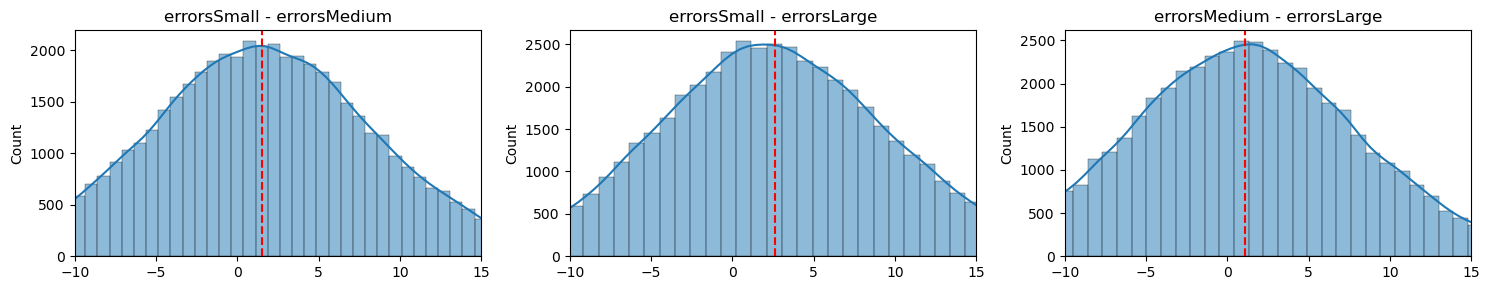

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram of one of the difference distributions 1x3 subplots
fig, ax = plt.subplots(1, 3, figsize=(15, 3))
sns.histplot(D_SM, bins=100, kde=True, ax=ax[0])
sns.histplot(D_SL, bins=100, kde=True, ax=ax[1])
sns.histplot(D_ML, bins=100, kde=True, ax=ax[2])
# set xlim to -10 to 10
ax[0].set_xlim(-10, 15)
ax[0].set_title("errorsSmall - errorsMedium")
ax[0].axvline(np.mean(D_SM), color='red', linestyle='--', label='Mean')
ax[1].set_xlim(-10, 15)
ax[1].set_title("errorsSmall - errorsLarge")
ax[1].axvline(np.mean(D_SL), color='red', linestyle='--', label='Mean')
ax[2].set_xlim(-10, 15)
ax[2].set_title("errorsMedium - errorsLarge")
ax[2].axvline(np.mean(D_ML), color='red', linestyle='--', label='Mean')
plt.tight_layout()
plt.show()

In [11]:
from scipy import stats
# Run paired t-test and Wilcoxon test for all pairs
def run_tests(errors1, errors2, label1, label2):
    t_stat, p_t = stats.ttest_rel(errors1, errors2)
    w_stat, p_w = stats.wilcoxon(errors1, errors2)
    
    print(f"Paired t-test between {label1} and {label2}: t = {t_stat:.3f}, p = {p_t:.4f}")
    print(f"Wilcoxon test between {label1} and {label2}: W = {w_stat:.3f}, p = {p_w:.4f}")

run_tests(errorsSmall, errorsMedium, "Small", "Medium")
run_tests(errorsSmall, errorsLarge, "Small", "Large")
run_tests(errorsMedium, errorsLarge, "Medium", "Large")

Paired t-test between Small and Medium: t = 44.710, p = 0.0000
Wilcoxon test between Small and Medium: W = 461266036.000, p = 0.0000
Paired t-test between Small and Large: t = 75.027, p = 0.0000
Wilcoxon test between Small and Large: W = 376724998.000, p = 0.0000
Paired t-test between Medium and Large: t = 32.529, p = 0.0000
Wilcoxon test between Medium and Large: W = 500367030.000, p = 0.0000


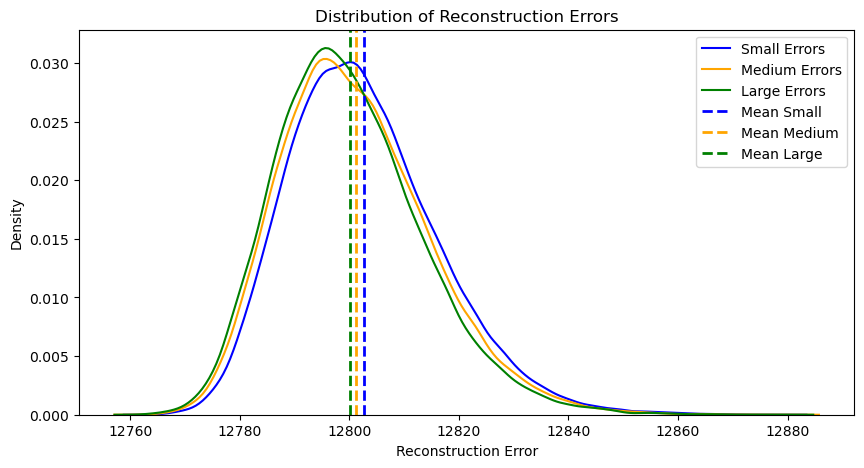

In [12]:
# plot the two distributions
plt.figure(figsize=(10, 5))
sns.kdeplot(errorsSmall, label='Small Errors', color='blue')
sns.kdeplot(errorsMedium, label='Medium Errors', color='orange')
sns.kdeplot(errorsLarge, label='Large Errors', color='green')
plt.axvline(np.mean(errorsSmall), color='blue', linestyle='--', linewidth=2, label='Mean Small')
plt.axvline(np.mean(errorsMedium), color='orange', linestyle='--', linewidth=2, label='Mean Medium')
plt.axvline(np.mean(errorsLarge), color='green', linestyle='--', linewidth=2, label='Mean Large')
plt.title("Distribution of Reconstruction Errors")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.legend()
plt.show()

In [14]:
def compute_cohen_d(errorsA, errorsB):
    diffs = errorsA - errorsB
    cohen_d = np.mean(diffs) / np.std(diffs, ddof=1)
    print(f"Cohen's d = {cohen_d:.3f}")

compute_cohen_d(errorsSmall, errorsMedium)
compute_cohen_d(errorsSmall, errorsLarge)
compute_cohen_d(errorsMedium, errorsLarge)

Cohen's d = 0.202
Cohen's d = 0.339
Cohen's d = 0.147


In [15]:
def bootstrap_ci(data, B=1000, alpha=0.05):
    boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(B)]
    lower = np.percentile(boot_means, 100*alpha/2)
    upper = np.percentile(boot_means, 100*(1 - alpha/2))
    return lower, upper

# Compute bootstrap confidence intervals for the means of each error distribci_S = bootstrap_ci(errorsSmall)
ci_L = bootstrap_ci(errorsLarge)
ci_M = bootstrap_ci(errorsMedium)
ci_S = bootstrap_ci(errorsLarge)
print(f"Bootstrap CI for Small Errors: {ci_S}")
print(f"Bootstrap CI for Medium Errors: {ci_M}")
print(f"Bootstrap CI for Large Errors: {ci_L}")

Bootstrap CI for Small Errors: (12799.895458984374, 12800.129907226563)
Bootstrap CI for Medium Errors: (12800.999975585937, 12801.2490234375)
Bootstrap CI for Large Errors: (12799.8974609375, 12800.134790039063)


In [50]:
from scipy.stats import spearmanr
def compute_spearman_correlation(errorsA, errorsB):
    print(f"Spearman correlation between errors: {spearmanr(errorsA, errorsB)}")

compute_spearman_correlation(errorsSmall, errorsMedium)
compute_spearman_correlation(errorsSmall, errorsLarge)
compute_spearman_correlation(errorsMedium, errorsLarge)

Spearman correlation between errors: SignificanceResult(statistic=0.9821254433806152, pvalue=0.0)
Spearman correlation between errors: SignificanceResult(statistic=0.9658417441839768, pvalue=0.0)
Spearman correlation between errors: SignificanceResult(statistic=0.9825250563662072, pvalue=0.0)


## VAE+

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "../experiments/models"

model_64 = load_model_and_cfg(model_path + "/LatentTest2/large_64.pth") # epoch 100
model_plus_small = load_model_and_cfg(model_path + "/VAEPlus/large_32_32_32_64_2.pth") # epoch 25

model_64.to(device)
model_plus_small.to(device)

VAEPlus(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(128, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (7): LeakyReLU(negative_slope=0.01)
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=6400, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=6400, out_features=64, bias=True)
  (decoder_input): Linear(in_features=64, out_features=6400, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(256, 5, 5))
    (1): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (2): LeakyReLU(negative_slope=0.01)
    (3): ConvTranspose2d(128, 64, kernel_size=(

In [44]:
from src.data_loading_well import load_data_by_well
cfg = model_64.cfg
val_loader = load_data_by_well(cfg, split="test")

Total wells Train: 770, Val: 96, Test: 96
Total images in test: 46458 (9.66% of total)


In [45]:
# (Re‐use the approach from before to get per-image errors in batches.)
# Suppose this function exists:
def all_test_reconstruction_errors(model, test_loader, device):
    model.eval()
    model.to(device)

    errors_list = []
    with torch.no_grad():
        for x_batch, _ in tqdm(test_loader, desc=f"Computing reconstruction errors for {model.cfg.model.name}"):
            x_batch = x_batch.to(device)

            mu, logvar = model.encode(x_batch)
            # reparameterization trick
            z = model.reparameterize(mu, logvar)
            recon = model.decode(z)

            # Compute per-image reconstruction loss manually (no .mean())
            squared_diff = ((recon - x_batch) ** 2).view(x_batch.size(0), -1).sum(dim=1)  # (B,)
            mse_term = 0.5 * squared_diff
            D = x_batch[0].numel()
            const = 0.5 * D * np.log(2 * np.pi)
            per_image_loss = mse_term + const  # shape: (B,)

            errors_list.append(per_image_loss.cpu().numpy())

    # Concatenate into one big (N_test,) tensor
    all_errors = np.concatenate(errors_list, axis=0)
    return all_errors

In [46]:
errors64 = all_test_reconstruction_errors(model_64, val_loader, device)  # shape = (N_test,)
errorsPlusSmall = all_test_reconstruction_errors(model_plus_small, val_loader, device)  # shape = (N_test,)

Computing reconstruction errors for VAE+: 100%|██████████| 182/182 [00:06<00:00, 27.78it/s]


In [47]:
# mean reconstruction error of each model
mean_error_64 = np.mean(errors64)
mean_error_plus_small = np.mean(errorsPlusSmall)

print(f"Mean reconstruction error for VAE64: {mean_error_64:.4f}")
print(f"Mean reconstruction error for VAEPlusSmall: {mean_error_plus_small:.4f}")

Mean reconstruction error for VAE64: 12799.4297
Mean reconstruction error for VAEPlusSmall: 12785.8770


In [48]:
import numpy as np
from scipy import stats

# 1) Compute pairwise difference‐vectors:
D_64_Plus = errors64 - errorsPlusSmall  # shape = (N_test,)

# 2) Run Shapiro-Wilk on each difference:
def check_normality(vec, label):
    W, pval = stats.shapiro(vec)
    print(f"Shapiro-Wilk for {label}: W = {W:.4f}, p = {pval:.4f}")
    if pval < 0.05:
        print(f"  → Distribution of {label} is likely NOT normal (p < 0.05).")
    else:
        print(f"  → No evidence to reject normality for {label} (p ≥ 0.05).")

check_normality(D_64_Plus, "errors64 - errorsPlusSmall")

Shapiro-Wilk for errors64 - errorsPlusSmall: W = 0.9918, p = 0.0000
  → Distribution of errors64 - errorsPlusSmall is likely NOT normal (p < 0.05).


e:\Anaconda\envs\VAE\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 46458.
  res = hypotest_fun_out(*samples, **kwds)


In [49]:
from scipy import stats
# Run paired t-test and Wilcoxon test for all pairs
def run_tests(errors1, errors2, label1, label2):
    t_stat, p_t = stats.ttest_rel(errors1, errors2)
    w_stat, p_w = stats.wilcoxon(errors1, errors2)
    
    print(f"Paired t-test between {label1} and {label2}: t = {t_stat:.3f}, p = {p_t:.4f}")
    print(f"Wilcoxon test between {label1} and {label2}: W = {w_stat:.3f}, p = {p_w:.4f}")

run_tests(errors64, errorsPlusSmall, "64", "PlusSmall")

Paired t-test between 64 and PlusSmall: t = 386.001, p = 0.0000
Wilcoxon test between 64 and PlusSmall: W = 3639361.000, p = 0.0000


In [50]:
def compute_cohen_d(errorsA, errorsB):
    diffs = errorsA - errorsB
    cohen_d = np.mean(diffs) / np.std(diffs, ddof=1)
    print(f"Cohen's d = {cohen_d:.3f}")

compute_cohen_d(errors64, errorsPlusSmall)

Cohen's d = 1.791


In [51]:
def bootstrap_ci(data, B=1000, alpha=0.05):
    boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(B)]
    lower = np.percentile(boot_means, 100*alpha/2)
    upper = np.percentile(boot_means, 100*(1 - alpha/2))
    return lower, upper

# Compute bootstrap confidence intervals for the means of each error distribution
ci_64 = bootstrap_ci(errors64)
ci_plus_small = bootstrap_ci(errorsPlusSmall)
print(f"Bootstrap CI for 64 Errors: {ci_64}")
print(f"Bootstrap CI for PlusSmall Errors: {ci_plus_small}")

Bootstrap CI for 64 Errors: (12799.306591796874, 12799.544921875)
Bootstrap CI for PlusSmall Errors: (12785.7666015625, 12785.974658203126)


In [52]:
from scipy.stats import spearmanr
def compute_spearman_correlation(errorsA, errorsB):
    print(f"Spearman correlation between errors: {spearmanr(errorsA, errorsB)}")

compute_spearman_correlation(errors64, errorsPlusSmall)

Spearman correlation between errors: SignificanceResult(statistic=0.8038711083726633, pvalue=0.0)


## Test Set

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelLarge64 = load_model_and_cfg("../experiments/models/LatentTest2/large_64.pth")
modelPlus64 = load_model_and_cfg("../experiments/models/VAEPlus/large_32_32_32_64_2.pth")

modelLarge64.to(device)
modelPlus64.to(device)

VAEPlus(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(128, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (7): LeakyReLU(negative_slope=0.01)
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=6400, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=6400, out_features=64, bias=True)
  (decoder_input): Linear(in_features=64, out_features=6400, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(256, 5, 5))
    (1): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (2): LeakyReLU(negative_slope=0.01)
    (3): ConvTranspose2d(128, 64, kernel_size=(

In [21]:
from src.data_loading_well import load_data_by_well
cfg = modelLarge64.cfg
val_loader = load_data_by_well(cfg, split="test")

Total wells Train: 770, Val: 96, Test: 96
Total images in test: 46458 (9.66% of total)


In [22]:
# (Re‐use the approach from before to get per-image errors in batches.)
# Suppose this function exists:
def all_test_reconstruction_errors(model, test_loader, device):
    model.eval()
    model.to(device)

    errors_list = []
    with torch.no_grad():
        for x_batch, _ in tqdm(test_loader, desc=f"Computing reconstruction errors for {model.cfg.model.name}"):
            x_batch = x_batch.to(device)

            mu, logvar = model.encode(x_batch)
            # reparameterization trick
            z = model.reparameterize(mu, logvar)
            recon = model.decode(z)

            # Compute per-image reconstruction loss manually (no .mean())
            squared_diff = ((recon - x_batch) ** 2).view(x_batch.size(0), -1).sum(dim=1)  # (B,)
            mse_term = 0.5 * squared_diff
            D = x_batch[0].numel()
            const = 0.5 * D * np.log(2 * np.pi)
            per_image_loss = mse_term + const  # shape: (B,)

            errors_list.append(per_image_loss.cpu().numpy())

    # Concatenate into one big (N_test,) tensor
    all_errors = np.concatenate(errors_list, axis=0)
    return all_errors

In [28]:
errorsLarge64 = all_test_reconstruction_errors(modelLarge64, val_loader, device)  # shape = (N_test,)
errorsPlus64 = all_test_reconstruction_errors(modelPlus64, val_loader, device)  # shape = (N_test,)

Computing reconstruction errors for VAE+: 100%|██████████| 182/182 [00:06<00:00, 27.02it/s]


In [29]:
# mean reconstruction error of each model
mean_error_large = np.mean(errorsLarge64)
mean_error_plus = np.mean(errorsPlus64)
print(f"Mean reconstruction error for VAE64: {mean_error_large:.4f}")
print(f"Mean reconstruction error for VAEPlus64: {mean_error_plus:.4f}")

Mean reconstruction error for VAE64: 12799.4795
Mean reconstruction error for VAEPlus64: 12785.8594


In [30]:
import numpy as np
from scipy import stats

# 1) Compute pairwise difference‐vectors:
D_64_Plus = errorsLarge64 - errorsPlus64  # shape = (N_test,)

# 2) Run Shapiro-Wilk on each difference:
def check_normality(vec, label):
    W, pval = stats.shapiro(vec)
    print(f"Shapiro-Wilk for {label}: W = {W:.4f}, p = {pval:.4f}")
    if pval < 0.05:
        print(f"  → Distribution of {label} is likely NOT normal (p < 0.05).")
    else:
        print(f"  → No evidence to reject normality for {label} (p ≥ 0.05).")

check_normality(D_64_Plus, "errors64 - errorsPlusSmall")

Shapiro-Wilk for errors64 - errorsPlusSmall: W = 0.9920, p = 0.0000
  → Distribution of errors64 - errorsPlusSmall is likely NOT normal (p < 0.05).


In [32]:
from scipy import stats
# Run paired t-test and Wilcoxon test for all pairs
def run_tests(errors1, errors2, label1, label2):
    t_stat, p_t = stats.ttest_rel(errors1, errors2)
    w_stat, p_w = stats.wilcoxon(errors1, errors2)
    
    print(f"Paired t-test between {label1} and {label2}: t = {t_stat:.3f}, p = {p_t:.4f}")
    print(f"Wilcoxon test between {label1} and {label2}: W = {w_stat:.3f}, p = {p_w:.4f}")

run_tests(errorsLarge64, errorsPlus64, "Large64", "Plus64")

Paired t-test between Large64 and Plus64: t = 387.885, p = 0.0000
Wilcoxon test between Large64 and Plus64: W = 3496438.000, p = 0.0000


In [37]:
def compute_cohen_d(errorsA, errorsB):
    diffs = errorsA - errorsB
    cohen_d = np.mean(diffs) / np.std(diffs, ddof=1)
    print(f"Cohen's d = {cohen_d:.3f}")

compute_cohen_d(errorsLarge64, errorsPlus64)

Cohen's d = 1.800


In [36]:
def bootstrap_ci(data, B=1000, alpha=0.05):
    boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(B)]
    lower = np.percentile(boot_means, 100*alpha/2)
    upper = np.percentile(boot_means, 100*(1 - alpha/2))
    return lower, upper

# Compute bootstrap confidence intervals for the means of each error distribution
ci_64 = bootstrap_ci(errorsLarge64)
ci_plus = bootstrap_ci(errorsPlus64)
print(f"Bootstrap CI for 64 Errors: {ci_64}")
print(f"Bootstrap CI for Plus Errors: {ci_plus}")

Bootstrap CI for 64 Errors: (12799.359350585937, 12799.5947265625)
Bootstrap CI for Plus Errors: (12785.756811523437, 12785.96484375)


# Parameters of models

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "../experiments/models"

modelSmall = load_model_and_cfg(model_path + "/VAESmall/small.pth")
modelMedium = load_model_and_cfg(model_path + "/VAEMedium/medium.pth")
modelLarge = load_model_and_cfg(model_path + "/VAELarge/large.pth")

modelSmall.to(device)
modelMedium.to(device)
modelLarge.to(device)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "../experiments/models/LatentTest2"
modelLarge32 = load_model_and_cfg(model_path + "/large_32.pth")
modelLarge64 = load_model_and_cfg(model_path + "/large_64.pth")
modelLarge128 = load_model_and_cfg(model_path + "/large_128.pth")
modelLarge256 = load_model_and_cfg(model_path + "/large_256.pth")

modelLarge32.to(device)
modelLarge64.to(device)
modelLarge128.to(device)
modelLarge256.to(device)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "../experiments/models/VAEPlus"
modelplus64 = load_model_and_cfg(model_path + "/large_32_32_32_64_2.pth")

modelplus64.to(device)

In [9]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Model size
print(f"Model Small:  {count_parameters(modelSmall):,} parameters")
print(f"Model Medium: {count_parameters(modelMedium):,} parameters")
print(f"Model Large:  {count_parameters(modelLarge):,} parameters")

# Latent size
print(f"Model Large 32: {count_parameters(modelLarge32):,} parameters")
print(f"Model Large 64: {count_parameters(modelLarge64):,} parameters")
print(f"Model Large 128: {count_parameters(modelLarge128):,} parameters")
print(f"Model Large 256: {count_parameters(modelLarge256):,} parameters")

# Plus size
print(f"Model PlusSmall: {count_parameters(modelplus64):,} parameters")

Model Small:  349,027 parameters
Model Medium: 774,339 parameters
Model Large:  7,078,019 parameters
Model Large 32: 2,776,771 parameters
Model Large 64: 3,391,235 parameters
Model Large 128: 4,620,163 parameters
Model Large 256: 7,078,019 parameters
Model PlusSmall: 3,497,796 parameters


In [10]:
from collections import defaultdict

def summarize_by_module(model):
    summary = defaultdict(int)
    for name, param in model.named_parameters():
        if param.requires_grad:
            group = name.split('.')[0]
            summary[group] += param.numel()
    for k, v in summary.items():
        print(f"{k:<15} {v:,} parameters")
    total_params = sum(summary.values())
    print(f"{'Total':<15} {total_params:,} parameters\n")

print("Model size summary:")
print("Model Small Summary:")
summarize_by_module(modelSmall)
print("Model Medium Summary:")
summarize_by_module(modelMedium)
print("Model Large Summary:")
summarize_by_module(modelLarge)

print("Model latent size summary:")
print("Model Large 32 Summary:")
summarize_by_module(modelLarge32)
print("Model Large 64 Summary:")
summarize_by_module(modelLarge64)
print("Model Large 128 Summary:")
summarize_by_module(modelLarge128)
print("Model Large 256 Summary:")
summarize_by_module(modelLarge256)

print("Model PlusSmall Summary:")
summarize_by_module(modelplus64)

Model size summary:
Model Small Summary:
encoder         20,464 parameters
fc_mu           102,656 parameters
fc_logvar       102,656 parameters
decoder_input   102,800 parameters
decoder         20,451 parameters
Total           349,027 parameters

Model Medium Summary:
encoder         79,328 parameters
fc_mu           205,056 parameters
fc_logvar       205,056 parameters
decoder_input   205,600 parameters
decoder         79,299 parameters
Total           774,339 parameters

Model Large Summary:
encoder         1,078,080 parameters
fc_mu           1,638,656 parameters
fc_logvar       1,638,656 parameters
decoder_input   1,644,800 parameters
decoder         1,077,827 parameters
Total           7,078,019 parameters

Model latent size summary:
Model Large 32 Summary:
encoder         1,078,080 parameters
fc_mu           204,832 parameters
fc_logvar       204,832 parameters
decoder_input   211,200 parameters
decoder         1,077,827 parameters
Total           2,776,771 parameters

Model L

# KL divergence

In [56]:
import torch
import numpy as np
from tqdm import tqdm

def all_test_kl_divergences(model, test_loader, device):
    model.eval()
    model.to(device)
    kl_list = []

    with torch.no_grad():
        for x_batch, _ in tqdm(test_loader, desc="Collecting KL divergences"):
            x_batch = x_batch.to(device)
            recon, mu, logvar = model(x_batch)

            # Per-image KL divergence: shape (batch_size,)
            kl_per_sample = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
            kl_list.append(kl_per_sample.cpu().numpy())

    # Flatten into a single array of shape (N_test,)
    return np.concatenate(kl_list, axis=0)


In [57]:
klSmall = all_test_kl_divergences(modelSmall, val_loader, device)  # shape = (N_test,)
klMedium = all_test_kl_divergences(modelMedium, val_loader, device)  # shape = (N_test,)
klLarge = all_test_kl_divergences(modelLarge, val_loader, device)  # shape = (N_test,)

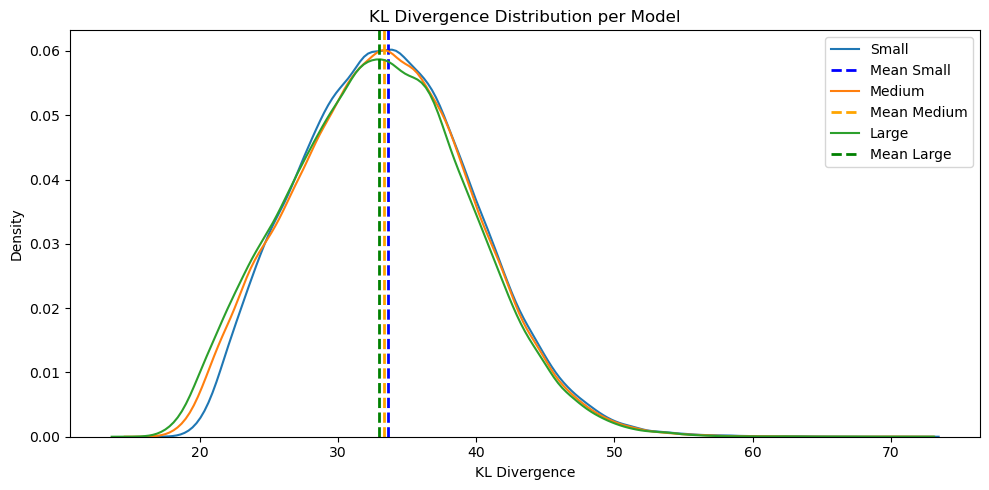

Small   mean ± std: 33.612 ± 6.247
Medium  mean ± std: 33.325 ± 6.382
Large   mean ± std: 32.981 ± 6.477

--- Paired t-tests and Wilcoxon signed-rank tests ---

Small vs Medium
  Δ mean = 0.2869
  Shapiro-Wilk (normality of differences): W = 0.9932, p = 7.047e-41
  Paired t-test:     t = 59.491, p = 0
  Wilcoxon test:     W = 405553210.0, p = 0
  Cohen's d:         d = 0.269

Small vs Large
  Δ mean = 0.6313
  Shapiro-Wilk (normality of differences): W = 0.9836, p = 1.826e-56
  Paired t-test:     t = 100.695, p = 0
  Wilcoxon test:     W = 293505910.0, p = 0
  Cohen's d:         d = 0.455

Medium vs Large
  Δ mean = 0.3444
  Shapiro-Wilk (normality of differences): W = 0.9856, p = 4.952e-54
  Paired t-test:     t = 73.181, p = 0
  Wilcoxon test:     W = 361904286.5, p = 0
  Cohen's d:         d = 0.331


e:\Anaconda\envs\VAE\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 48891.
  res = hypotest_fun_out(*samples, **kwds)


In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon, shapiro

# --- Helper: Cohen's d for paired samples
def cohen_d_paired(a, b):
    diff = a - b
    return np.mean(diff) / np.std(diff, ddof=1)

# --- 1. KDE plot
plt.figure(figsize=(10, 5))
sns.kdeplot(klSmall, label="Small")
plt.axvline(klSmall.mean(), color='blue', linestyle='--', linewidth=2, label='Mean Small')
sns.kdeplot(klMedium, label="Medium")
plt.axvline(klMedium.mean(), color='orange', linestyle='--', linewidth=2, label='Mean Medium')
sns.kdeplot(klLarge, label="Large")
plt.axvline(klLarge.mean(), color='green', linestyle='--', linewidth=2, label='Mean Large')
plt.xlabel("KL Divergence")
plt.ylabel("Density")
plt.title("KL Divergence Distribution per Model")
plt.legend()
plt.tight_layout()
plt.savefig("kld_kde_plot.png")
plt.show()

# --- 2. Summary stats
for name, data in zip(["Small", "Medium", "Large"], [klSmall, klMedium, klLarge]):
    print(f"{name:7s} mean ± std: {data.mean():.3f} ± {data.std():.3f}")

# --- 3. Pairwise comparisons
pairs = [("Small", "Medium", klSmall, klMedium),
         ("Small", "Large",  klSmall, klLarge),
         ("Medium", "Large", klMedium, klLarge)]

pvals_t = []
pvals_w = []
print("\n--- Paired t-tests and Wilcoxon signed-rank tests ---")
for name_a, name_b, a, b in pairs:
    diff = a - b
    t_stat, t_p = ttest_rel(a, b)
    w_stat, w_p = wilcoxon(a, b)
    norm_stat, norm_p = shapiro(diff)

    d = cohen_d_paired(a, b)

    print(f"\n{name_a} vs {name_b}")
    print(f"  Δ mean = {np.mean(diff):.4f}")
    print(f"  Shapiro-Wilk (normality of differences): W = {norm_stat:.4f}, p = {norm_p:.4g}")
    print(f"  Paired t-test:     t = {t_stat:.3f}, p = {t_p:.4g}")
    print(f"  Wilcoxon test:     W = {w_stat:.1f}, p = {w_p:.4g}")
    print(f"  Cohen's d:         d = {d:.3f}")

    pvals_t.append(t_p)
    pvals_w.append(w_p)

# ELBO's

## Model size

In [5]:
import torch
import numpy as np
from tqdm import tqdm

def all_test_elbos(model, test_loader, device):
    model.eval()
    model.to(device)

    elbo_list = []
    with torch.no_grad():
        for x_batch, _ in tqdm(test_loader, desc="Computing ELBOs"):
            x_batch = x_batch.to(device)
            # reparameterization trick
            mu, logvar = model.encode(x_batch)
            # z = model.reparameterize(mu, logvar)
            recon = model.decode(mu)

            # Compute per-image ELBO (reconstruction + KL)
            recon_loss = 0.5 * ((recon - x_batch) ** 2).view(x_batch.size(0), -1).sum(dim=1)
            D = x_batch[0].numel()
            const = 0.5 * D * np.log(2 * np.pi)
            recon_loss += const

            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)

            elbo = (recon_loss + kl_loss).cpu().numpy()  # (B,)
            elbo_list.append(elbo)

    return np.concatenate(elbo_list, axis=0)  # shape: (N_test,)

In [6]:
elboSmall = all_test_elbos(modelSmall, val_loader, device)  # shape = (N_test,)
elboMedium = all_test_elbos(modelMedium, val_loader, device)  # shape = (N_test,)
elboLarge = all_test_elbos(modelLarge, val_loader, device)  # shape = (N_test,)

Computing ELBOs:   0%|          | 0/191 [00:00<?, ?it/s]

Computing ELBOs: 100%|██████████| 191/191 [00:07<00:00, 25.86it/s]


In [7]:
# mean ELBO of each model
mean_elbo_small = np.mean(elboSmall)
mean_elbo_medium = np.mean(elboMedium)
mean_elbo_large = np.mean(elboLarge)
print(f"Mean ELBO for VAESmall: {mean_elbo_small:.4f}")
print(f"Mean ELBO for VAEMedium: {mean_elbo_medium:.4f}")
print(f"Mean ELBO for VAELarge: {mean_elbo_large:.4f}")

Mean ELBO for VAESmall: 12821.9229
Mean ELBO for VAEMedium: 12820.5010
Mean ELBO for VAELarge: 12819.3047


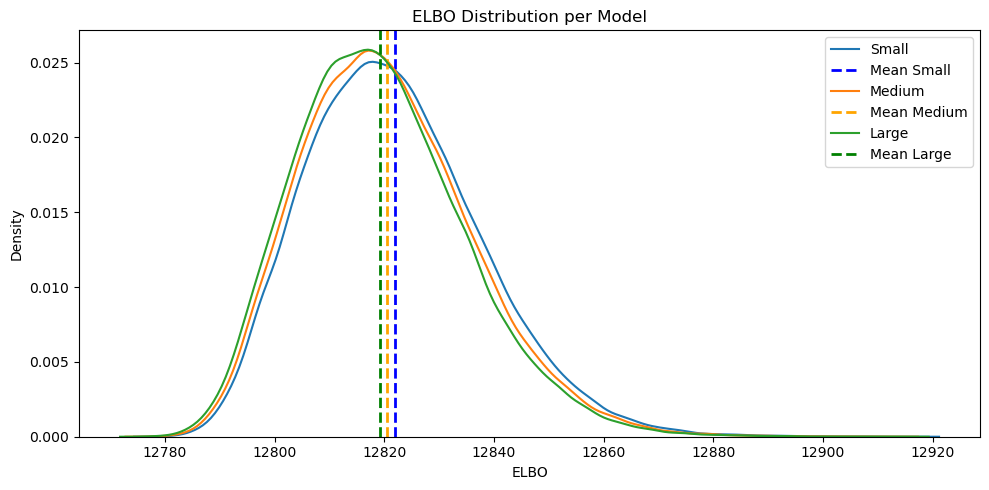

Small   mean ± std: 12821.923 ± 15.942
Medium  mean ± std: 12820.501 ± 15.617
Large   mean ± std: 12819.305 ± 15.424

--- Paired t-tests and Wilcoxon signed-rank tests ---

Small vs Medium
  Δ mean = 1.4221
  Shapiro-Wilk (normality of differences): W = 0.9639, p = 1.307e-72
  Paired t-test:     t = 166.494, p = 0
  Wilcoxon test:     W = 146447254.0, p = 0
  Cohen's d:         d = 0.753

Small vs Large
  Δ mean = 2.6197
  Shapiro-Wilk (normality of differences): W = 0.9289, p = 4.596e-88
  Paired t-test:     t = 206.393, p = 0
  Wilcoxon test:     W = 71836524.5, p = 0
  Cohen's d:         d = 0.933

Medium vs Large
  Δ mean = 1.1976
  Shapiro-Wilk (normality of differences): W = 0.9402, p = 5.43e-84
  Paired t-test:     t = 131.857, p = 0
  Wilcoxon test:     W = 212732400.0, p = 0
  Cohen's d:         d = 0.596


e:\Anaconda\envs\VAE\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 48891.
  res = hypotest_fun_out(*samples, **kwds)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon, shapiro

# --- Helper: Cohen's d for paired samples
def cohen_d_paired(a, b):
    diff = a - b
    return np.mean(diff) / np.std(diff, ddof=1)

# --- 1. KDE plot
plt.figure(figsize=(10, 5))
sns.kdeplot(elboSmall, label="Small")
plt.axvline(elboSmall.mean(), color='blue', linestyle='--', linewidth=2, label='Mean Small')
sns.kdeplot(elboMedium, label="Medium")
plt.axvline(elboMedium.mean(), color='orange', linestyle='--', linewidth=2, label='Mean Medium')
sns.kdeplot(elboLarge, label="Large")
plt.axvline(elboLarge.mean(), color='green', linestyle='--', linewidth=2, label='Mean Large')
plt.xlabel("ELBO")
plt.ylabel("Density")
plt.title("ELBO Distribution per Model")
plt.legend()
plt.tight_layout()
plt.savefig("elbo_kde_plot.png")
plt.show()

# --- 2. Summary stats
for name, data in zip(["Small", "Medium", "Large"], [elboSmall, elboMedium, elboLarge]):
    print(f"{name:7s} mean ± std: {data.mean():.3f} ± {data.std():.3f}")

# --- 3. Pairwise comparisons
pairs = [("Small", "Medium", elboSmall, elboMedium),
         ("Small", "Large",  elboSmall, elboLarge),
         ("Medium", "Large", elboMedium, elboLarge)]

pvals_t = []
pvals_w = []
print("\n--- Paired t-tests and Wilcoxon signed-rank tests ---")
for name_a, name_b, a, b in pairs:
    diff = a - b
    t_stat, t_p = ttest_rel(a, b)
    w_stat, w_p = wilcoxon(a, b)
    norm_stat, norm_p = shapiro(diff)

    d = cohen_d_paired(a, b)

    print(f"\n{name_a} vs {name_b}")
    print(f"  Δ mean = {np.mean(diff):.4f}")
    print(f"  Shapiro-Wilk (normality of differences): W = {norm_stat:.4f}, p = {norm_p:.4g}")
    print(f"  Paired t-test:     t = {t_stat:.3f}, p = {t_p:.4g}")
    print(f"  Wilcoxon test:     W = {w_stat:.1f}, p = {w_p:.4g}")
    print(f"  Cohen's d:         d = {d:.3f}")

    pvals_t.append(t_p)
    pvals_w.append(w_p)

In [9]:
def bootstrap_ci(data, B=10000, alpha=0.05):
    boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(B)]
    bonf_alpha = alpha / 3  # Bonferroni correction for 3 comparisons
    lower = np.percentile(boot_means, 100*bonf_alpha/2)
    upper = np.percentile(boot_means, 100*(1 - bonf_alpha/2))
    return lower, upper

# Compute bootstrap confidence intervals for the means of each error distribution
ci_S = bootstrap_ci(elboSmall)
ci_M = bootstrap_ci(elboMedium)
ci_L = bootstrap_ci(elboLarge)
print(f"Bootstrap CI for Small Errors: {ci_S}")
print(f"Bootstrap CI for Medium Errors: {ci_M}")
print(f"Bootstrap CI for Large Errors: {ci_L}")

Bootstrap CI for Small Errors: (12821.748046875, 12822.096044921875)
Bootstrap CI for Medium Errors: (12820.328125, 12820.6708984375)
Bootstrap CI for Large Errors: (12819.1396484375, 12819.478515625)


## Latent

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "../experiments/models/LatentTest2"
modelLarge32 = load_model_and_cfg(model_path + "/large_32.pth")
modelLarge64 = load_model_and_cfg(model_path + "/large_64.pth")
modelLarge128 = load_model_and_cfg(model_path + "/large_128.pth")
modelLarge256 = load_model_and_cfg(model_path + "/large_256.pth")

modelLarge32.to(device)
modelLarge64.to(device)
modelLarge128.to(device)
modelLarge256.to(device)

VAELarge(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(128, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (7): LeakyReLU(negative_slope=0.01)
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=6400, out_features=256, bias=True)
  (fc_logvar): Linear(in_features=6400, out_features=256, bias=True)
  (decoder_input): Linear(in_features=256, out_features=6400, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(256, 5, 5))
    (1): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (2): LeakyReLU(negative_slope=0.01)
    (3): ConvTranspose2d(128, 64, kernel_si

In [6]:
from src.data_loading_well import load_data_by_well
cfg = modelLarge32.cfg
val_loader = load_data_by_well(cfg, split="val")

Total wells Train: 770, Val: 96, Test: 96
Total images in val: 48891 (10.17% of total)


In [11]:
large32 = all_test_elbos(modelLarge32, val_loader, device)  # shape = (N_test,)
large64 = all_test_elbos(modelLarge64, val_loader, device)  # shape = (N_test,)
large128 = all_test_elbos(modelLarge128, val_loader, device)  # shape = (N_test,)
large256 = all_test_elbos(modelLarge256, val_loader, device)  # shape = (N_test,)

Computing ELBOs: 100%|██████████| 191/191 [00:07<00:00, 25.74it/s]


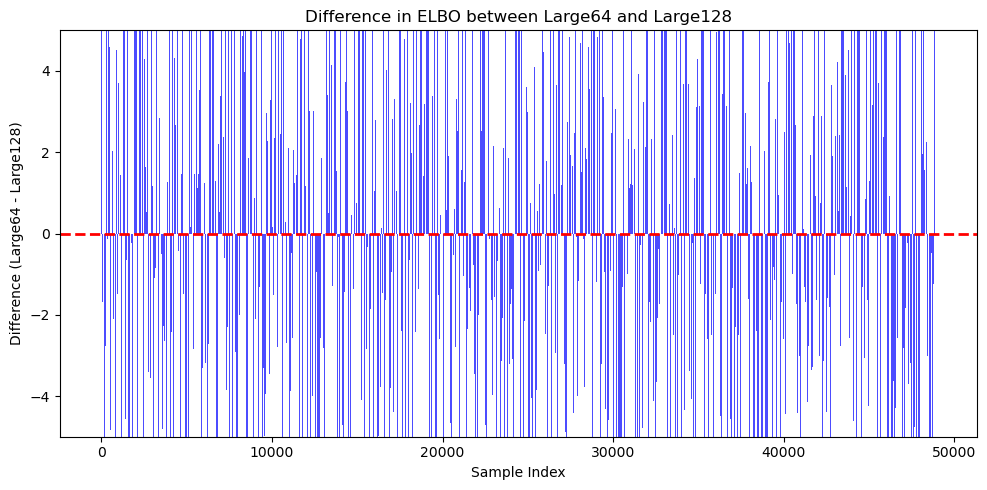

In [23]:
import numpy as np
import matplotlib.pyplot as plt
# plot bar plot of large32 - large64
D_64_128 = large64 - large128

# plot bar plot
plt.figure(figsize=(10, 5))
plt.bar(range(len(D_64_128)), D_64_128, color='blue', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Line')
plt.xlabel("Sample Index")
plt.ylabel("Difference (Large64 - Large128)")
plt.title("Difference in ELBO between Large64 and Large128")
plt.ylim(-5, 5)
plt.tight_layout()
plt.show()

In [24]:
better_64 = (large64 < large128).sum()
better_128 = (large128 < large64).sum()

print(f"Large64 wins: {better_64} samples")
print(f"Large128 wins: {better_128} samples")

Large64 wins: 24288 samples
Large128 wins: 24601 samples


In [12]:
# mean ELBO of each model
mean_elbo_large32 = np.mean(large32)
mean_elbo_large64 = np.mean(large64)
mean_elbo_large128 = np.mean(large128)
mean_elbo_large256 = np.mean(large256)
print(f"Mean ELBO for VAELarge 32: {mean_elbo_large32:.4f}")
print(f"Mean ELBO for VAELarge 64: {mean_elbo_large64:.4f}")
print(f"Mean ELBO for VAELarge 128: {mean_elbo_large128:.4f}")
print(f"Mean ELBO for VAELarge 256: {mean_elbo_large256:.4f}")

Mean ELBO for VAELarge 32: 12821.5352
Mean ELBO for VAELarge 64: 12819.0029
Mean ELBO for VAELarge 128: 12819.0098
Mean ELBO for VAELarge 256: 12819.3047


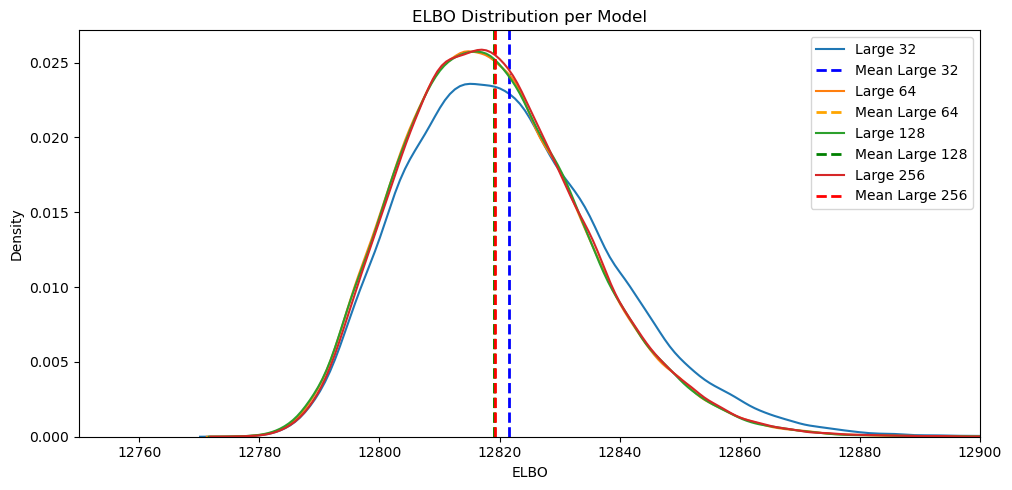

Large 32 mean ± std: 12821.535 ± 17.050
Large 64 mean ± std: 12819.003 ± 15.445
Large 128 mean ± std: 12819.010 ± 15.455
Large 256 mean ± std: 12819.305 ± 15.424

--- Paired t-tests and Wilcoxon signed-rank tests ---

Large 32 vs Large 64
  Δ mean = 2.5311
  Shapiro-Wilk (normality of differences): W = 0.8949, p = 1.062e-97
  Paired t-test:     t = 189.580, p = 0
  Wilcoxon test:     W = 80038720.5, p = 0
  Cohen's d:         d = 0.857
  Gap in means:          2.5322

Large 32 vs Large 128
  Δ mean = 2.5244
  Shapiro-Wilk (normality of differences): W = 0.8914, p = 1.582e-98
  Paired t-test:     t = 191.613, p = 0
  Wilcoxon test:     W = 74798380.0, p = 0
  Cohen's d:         d = 0.867
  Gap in means:          2.5254

Large 32 vs Large 256
  Δ mean = 2.2308
  Shapiro-Wilk (normality of differences): W = 0.9004, p = 2.443e-96
  Paired t-test:     t = 165.924, p = 0
  Wilcoxon test:     W = 126727038.5, p = 0
  Cohen's d:         d = 0.750
  Gap in means:          2.2305

Large 64 vs La

e:\Anaconda\envs\VAE\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 48891.
  res = hypotest_fun_out(*samples, **kwds)


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon, shapiro

# --- Helper: Cohen's d for paired samples
def cohen_d_paired(a, b):
    diff = a - b
    return np.mean(diff) / np.std(diff, ddof=1)

# --- 1. KDE plot
plt.figure(figsize=(10, 5))
sns.kdeplot(large32, label="Large 32")
plt.axvline(large32.mean(), color='blue', linestyle='--', linewidth=2, label='Mean Large 32')
sns.kdeplot(large64, label="Large 64")
plt.axvline(large64.mean(), color='orange', linestyle='--', linewidth=2, label='Mean Large 64')
sns.kdeplot(large128, label="Large 128")
plt.axvline(large128.mean(), color='green', linestyle='--', linewidth=2, label='Mean Large 128')
sns.kdeplot(large256, label="Large 256")
plt.axvline(large256.mean(), color='red', linestyle='--', linewidth=2, label='Mean Large 256')
plt.xlabel("ELBO")
plt.ylabel("Density")
plt.title("ELBO Distribution per Model")
plt.legend()
plt.tight_layout()
plt.xlim(12750, 12900)  # Set xlim to -100 to 100
plt.savefig("elbo_kde_plot.png")
plt.show()

# --- 2. Summary stats
for name, data in zip(["Large 32", "Large 64", "Large 128", "Large 256"], [large32, large64, large128, large256]):
    print(f"{name:7s} mean ± std: {data.mean():.3f} ± {data.std():.3f}")

# --- 3. Pairwise comparisons
pairs = [("Large 32", "Large 64", large32, large64),
         ("Large 32", "Large 128", large32, large128),
         ("Large 32", "Large 256", large32, large256),
         ("Large 64", "Large 128", large64, large128),
         ("Large 64", "Large 256", large64, large256),
         ("Large 128", "Large 256", large128, large256)]

pvals_t = []
pvals_w = []
print("\n--- Paired t-tests and Wilcoxon signed-rank tests ---")
for name_a, name_b, a, b in pairs:
    diff = a - b
    t_stat, t_p = ttest_rel(a, b)
    w_stat, w_p = wilcoxon(a, b)
    norm_stat, norm_p = shapiro(diff)

    d = cohen_d_paired(a, b)

    print(f"\n{name_a} vs {name_b}")
    print(f"  Δ mean = {np.mean(diff):.4f}")
    print(f"  Shapiro-Wilk (normality of differences): W = {norm_stat:.4f}, p = {norm_p:.4g}")
    print(f"  Paired t-test:     t = {t_stat:.3f}, p = {t_p:.4g}")
    print(f"  Wilcoxon test:     W = {w_stat:.1f}, p = {w_p:.4g}")
    print(f"  Cohen's d:         d = {d:.3f}")
    print(f"  Gap in means:          {np.mean(a) - np.mean(b):.4f}")

    pvals_t.append(t_p)
    pvals_w.append(w_p)

In [14]:
def bootstrap_ci(data, B=10000, alpha=0.05):
    boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(B)]
    bonf_alpha = alpha / 6  # Bonferroni correction for 6 comparisons
    lower = np.percentile(boot_means, 100*bonf_alpha/2)
    upper = np.percentile(boot_means, 100*(1 - bonf_alpha/2))
    return lower, upper

# Compute bootstrap confidence intervals for the means of each error distribution
ci_L32 = bootstrap_ci(large32)
ci_L64 = bootstrap_ci(large64)
ci_L128 = bootstrap_ci(large128)
ci_L256 = bootstrap_ci(large256)
print(f"Bootstrap CI for Large 32 Errors: {ci_L32}")
print(f"Bootstrap CI for Large 64 Errors: {ci_L64}")
print(f"Bootstrap CI for Large 128 Errors: {ci_L128}")
print(f"Bootstrap CI for Large 256 Errors: {ci_L256}")

Bootstrap CI for Large 32 Errors: (12821.3232421875, 12821.740234375)
Bootstrap CI for Large 64 Errors: (12818.8203125, 12819.1826171875)
Bootstrap CI for Large 128 Errors: (12818.830078125, 12819.194665527344)
Bootstrap CI for Large 256 Errors: (12819.121740722656, 12819.487963867188)


In [15]:
val_loader = load_data_by_well(cfg, split="train")

Total wells Train: 770, Val: 96, Test: 96
Total images in train: 385414 (80.17% of total)


In [16]:
large32 = all_test_elbos(modelLarge32, val_loader, device)  # shape = (N_test,)
large64 = all_test_elbos(modelLarge64, val_loader, device)  # shape = (N_test,)
large128 = all_test_elbos(modelLarge128, val_loader, device)  # shape = (N_test,)
large256 = all_test_elbos(modelLarge256, val_loader, device)  # shape = (N_test,)

Computing ELBOs: 100%|██████████| 1505/1505 [01:42<00:00, 14.62it/s]


In [17]:
# find mean of each
print(f"Mean ELBO for VAELarge 32 (train): {np.mean(large32):.2f}")
print(f"Mean ELBO for VAELarge 64 (train): {np.mean(large64):.2f}")
print(f"Mean ELBO for VAELarge 128 (train): {np.mean(large128):.2f}")
print(f"Mean ELBO for VAELarge 256 (train): {np.mean(large256):.2f}")

Mean ELBO for VAELarge 32 (train): 12820.68
Mean ELBO for VAELarge 64 (train): 12818.30
Mean ELBO for VAELarge 128 (train): 12818.32
Mean ELBO for VAELarge 256 (train): 12818.59


## VAE+

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "../experiments/models/VAEPlus"
modelplus64 = load_model_and_cfg(model_path + "/large_32_32_32_64_2.pth")

modelplus64.to(device)

VAEPlus(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(128, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (7): LeakyReLU(negative_slope=0.01)
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=6400, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=6400, out_features=64, bias=True)
  (decoder_input): Linear(in_features=64, out_features=6400, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(256, 5, 5))
    (1): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (2): LeakyReLU(negative_slope=0.01)
    (3): ConvTranspose2d(128, 64, kernel_size=(

In [ ]:
from src.data_loading_well import load_data_by_well
cfg = modelplus64.cfg
val_loader = load_data_by_well(cfg, split="val")

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

def all_test_elbos(model, test_loader, device):
    model.eval()
    model.to(device)

    elbo_list = []
    with torch.no_grad():
        for x_batch, _ in tqdm(test_loader, desc="Computing ELBOs"):
            x_batch = x_batch.to(device)
            # reparameterization trick
            mu, logvar = model.encode(x_batch)
            # z = model.reparameterize(mu, logvar)
            recon = model.decode(mu)

            # Compute per-image ELBO (reconstruction + KL)
            recon_loss = 0.5 * ((recon - x_batch) ** 2).view(x_batch.size(0), -1).sum(dim=1)
            D = x_batch[0].numel()
            const = 0.5 * D * np.log(2 * np.pi)
            recon_loss += const

            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)

            elbo = (recon_loss + kl_loss).cpu().numpy()  # (B,)
            elbo_list.append(elbo)

    return np.concatenate(elbo_list, axis=0)  # shape: (N_test,)

In [18]:
plus64 = all_test_elbos(modelplus64, val_loader, device)  # shape = (N_test,)

Computing ELBOs: 100%|██████████| 191/191 [01:07<00:00,  2.85it/s]


In [19]:
# mean ELBO of each model
mean_elbo_plus64 = np.mean(plus64)
print(f"Mean ELBO for VAEPlus 64: {mean_elbo_plus64:.4f}")

Mean ELBO for VAEPlus 64: 12878.2021


In [21]:
def bootstrap_ci(data, B=10000, alpha=0.05):
    boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(B)]
    bonf_alpha = alpha / 1  # Bonferroni correction for 1 comparison
    lower = np.percentile(boot_means, 100*bonf_alpha/2)
    upper = np.percentile(boot_means, 100*(1 - bonf_alpha/2))
    return lower, upper

# Compute bootstrap confidence intervals for the means of each error distribution
ci_Plus_64 = bootstrap_ci(plus64)
print(f"Bootstrap CI for VAEPlus 64 Errors: {ci_Plus_64}")

Bootstrap CI for VAEPlus 64 Errors: (12878.0224609375, 12878.384765625)


## Test SET

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelLarge64 = load_model_and_cfg("../experiments/models/LatentTest2/large_64.pth")
modelPlus64 = load_model_and_cfg("../experiments/models/VAEPlus/large_32_32_32_64_2.pth")

modelLarge64.to(device)
modelPlus64.to(device)

VAEPlus(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(128, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (7): LeakyReLU(negative_slope=0.01)
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=6400, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=6400, out_features=64, bias=True)
  (decoder_input): Linear(in_features=64, out_features=6400, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(256, 5, 5))
    (1): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (2): LeakyReLU(negative_slope=0.01)
    (3): ConvTranspose2d(128, 64, kernel_size=(

In [ ]:
from src.data_loading_well import load_data_by_well
cfg = modelLarge64.cfg
val_loader = load_data_by_well(cfg, split="test")

Total wells Train: 770, Val: 96, Test: 96
Total images in test: 46458 (9.66% of total)


In [ ]:
large64 = all_test_elbos(modelLarge64, val_loader, device)  # shape = (N_test,)
plus64 = all_test_elbos(modelPlus64, val_loader, device)  # shape = (N_test,)

Computing ELBOs: 100%|██████████| 182/182 [00:08<00:00, 22.54it/s]


In [ ]:
# mean ELBO of each model
mean_elbo_large64 = np.mean(large64)
mean_elbo_plus64 = np.mean(plus64)
print(f"Mean ELBO for VAELarge 64: {mean_elbo_large64:.4f}")
print(f"Mean ELBO for VAEPlus 64: {mean_elbo_plus64:.4f}")

Mean ELBO for VAELarge 64: 12819.0254
Mean ELBO for VAEPlus 64: 12878.4746


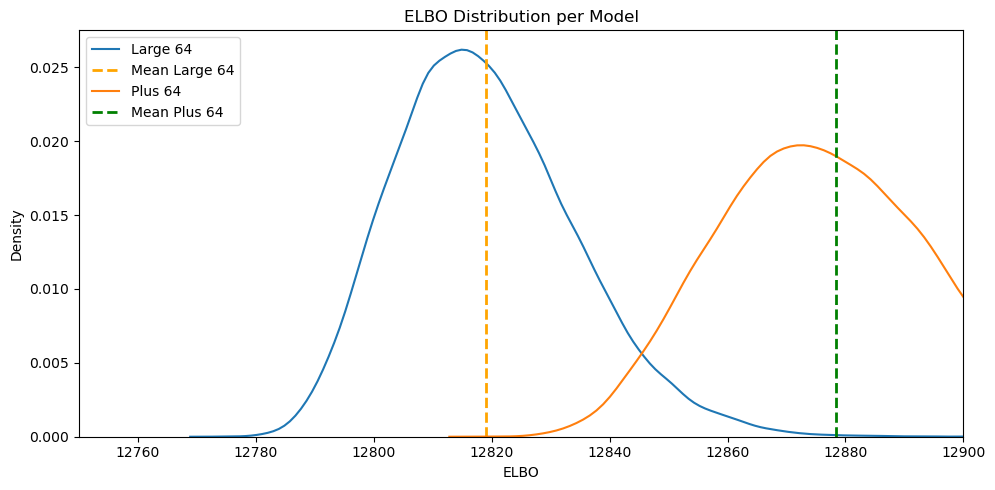

Large 64 mean ± std: 12819.025 ± 15.380
Plus 64 mean ± std: 12878.475 ± 20.467

--- Paired t-tests and Wilcoxon signed-rank tests ---

Large 64 vs Plus 64
  Δ mean = -59.4479
  Shapiro-Wilk (normality of differences): W = 0.9672, p = 1.334e-69
  Paired t-test:     t = -1291.132, p = 0
  Wilcoxon test:     W = 0.0, p = 0
  Cohen's d:         d = -5.990
  Gap in means:          -59.4492


e:\Anaconda\envs\VAE\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 46458.
  res = hypotest_fun_out(*samples, **kwds)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon, shapiro

# --- Helper: Cohen's d for paired samples
def cohen_d_paired(a, b):
    diff = a - b
    return np.mean(diff) / np.std(diff, ddof=1)

# --- 1. KDE plot
plt.figure(figsize=(10, 5))
sns.kdeplot(large64, label="Large 64")
plt.axvline(large64.mean(), color='orange', linestyle='--', linewidth=2, label='Mean Large 64')
sns.kdeplot(plus64, label="Plus 64")
plt.axvline(plus64.mean(), color='green', linestyle='--', linewidth=2, label='Mean Plus 64')
plt.xlabel("ELBO")
plt.ylabel("Density")
plt.title("ELBO Distribution per Model")
plt.legend()
plt.tight_layout()
plt.xlim(12750, 12900)  # Set xlim to -100 to 100
plt.savefig("elbo_kde_plot.png")
plt.show()

# --- 2. Summary stats
for name, data in zip(["Large 64", "Plus 64"], [large64, plus64]):
    print(f"{name:7s} mean ± std: {data.mean():.3f} ± {data.std():.3f}")

# --- 3. Pairwise comparisons
pairs = [("Large 64", "Plus 64", large64, plus64)]

pvals_t = []
pvals_w = []
print("\n--- Paired t-tests and Wilcoxon signed-rank tests ---")
for name_a, name_b, a, b in pairs:
    diff = a - b
    t_stat, t_p = ttest_rel(a, b)
    w_stat, w_p = wilcoxon(a, b)
    norm_stat, norm_p = shapiro(diff)

    d = cohen_d_paired(a, b)

    print(f"\n{name_a} vs {name_b}")
    print(f"  Δ mean = {np.mean(diff):.4f}")
    print(f"  Shapiro-Wilk (normality of differences): W = {norm_stat:.4f}, p = {norm_p:.4g}")
    print(f"  Paired t-test:     t = {t_stat:.3f}, p = {t_p:.4g}")
    print(f"  Wilcoxon test:     W = {w_stat:.1f}, p = {w_p:.4g}")
    print(f"  Cohen's d:         d = {d:.3f}")
    print(f"  Gap in means:          {np.mean(a) - np.mean(b):.4f}")

    pvals_t.append(t_p)
    pvals_w.append(w_p)

In [20]:
def bootstrap_ci(data, B=10000, alpha=0.05):
    boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(B)]
    bonf_alpha = alpha / 1  # Bonferroni correction for 6 comparisons
    lower = np.percentile(boot_means, 100*bonf_alpha/2)
    upper = np.percentile(boot_means, 100*(1 - bonf_alpha/2))
    return lower, upper

# Compute bootstrap confidence intervals for the means of each error distribution
ci_L64 = bootstrap_ci(large64)
ci_Plus64 = bootstrap_ci(plus64)
print(f"Bootstrap CI for Large 64 Errors: {ci_L64}")
print(f"Bootstrap CI for Plus 64 Errors: {ci_Plus64}")

Bootstrap CI for Large 64 Errors: (12818.8876953125, 12819.16796875)
Bootstrap CI for Plus 64 Errors: (12878.2880859375, 12878.65625)


In [ ]:
val_loader = load_data_by_well(cfg, split="train")

Total wells Train: 770, Val: 96, Test: 96
Total images in train: 385414 (80.17% of total)


In [ ]:
large32 = all_test_elbos(modelLarge32, val_loader, device)  # shape = (N_test,)
large64 = all_test_elbos(modelLarge64, val_loader, device)  # shape = (N_test,)
large128 = all_test_elbos(modelLarge128, val_loader, device)  # shape = (N_test,)
large256 = all_test_elbos(modelLarge256, val_loader, device)  # shape = (N_test,)

Computing ELBOs: 100%|██████████| 1505/1505 [01:42<00:00, 14.62it/s]


In [ ]:
# find mean of each
print(f"Mean ELBO for VAELarge 32 (train): {np.mean(large32):.2f}")
print(f"Mean ELBO for VAELarge 64 (train): {np.mean(large64):.2f}")
print(f"Mean ELBO for VAELarge 128 (train): {np.mean(large128):.2f}")
print(f"Mean ELBO for VAELarge 256 (train): {np.mean(large256):.2f}")

Mean ELBO for VAELarge 32 (train): 12820.68
Mean ELBO for VAELarge 64 (train): 12818.30
Mean ELBO for VAELarge 128 (train): 12818.32
Mean ELBO for VAELarge 256 (train): 12818.59


# NSC

In [19]:
import sys
import os

# Add the src directory to the Python path
sys.path.append(os.path.abspath("../"))
# KMP_DUPLICATE_LIB_OK=TRUE

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [ ]:
# McNemar's test for paired nominal data.
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

def load_correctness(pred_pairs):
    """Convert (true, pred) pairs into binary correctness array."""
    return np.array([int(t == p) for t, p in pred_pairs])

def mcnemar_test(correct1, correct2):
    """Perform McNemar's test on two binary correctness vectors."""
    table = np.zeros((2, 2), dtype=int)
    for c1, c2 in zip(correct1, correct2):
        table[c1, c2] += 1
    result = mcnemar(table, exact=True)
    return result.statistic, result.pvalue

# Load predictions (true, pred) pairs
small_preds = np.load("../nsc_compound_preds_small.npy")
medium_preds = np.load("../nsc_compound_preds_medium.npy")
large_preds = np.load("../nsc_compound_preds_large.npy")

# # Convert to binary correctness arrays 
small_correct = load_correctness(small_preds)
medium_correct = load_correctness(medium_preds)
large_correct = load_correctness(large_preds)

# Run McNemar's test for all pairs
stat_sm, p_sm = mcnemar_test(small_correct, medium_correct)
stat_sl, p_sl = mcnemar_test(small_correct, large_correct)
stat_ml, p_ml = mcnemar_test(medium_correct, large_correct)

# Report
print(f"McNemar's test Small vs Medium: statistic = {stat_sm:.3f}, p-value = {p_sm:.4f}")
print(f"McNemar's test Small vs Large:  statistic = {stat_sl:.3f}, p-value = {p_sl:.4f}")
print(f"McNemar's test Medium vs Large: statistic = {stat_ml:.3f}, p-value = {p_ml:.4f}")

McNemar's test Small vs Medium: statistic = 1.000, p-value = 0.6250
McNemar's test Small vs Large:  statistic = 0.000, p-value = 0.5000
McNemar's test Medium vs Large: statistic = 1.000, p-value = 1.0000


In [3]:
# McNemar's test for paired nominal data.
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

def load_correctness(pred_pairs):
    """Convert (true, pred) pairs into binary correctness array."""
    return np.array([int(t == p) for t, p in pred_pairs])

def mcnemar_test(correct1, correct2):
    """Perform McNemar's test on two binary correctness vectors."""
    table = np.zeros((2, 2), dtype=int)
    for c1, c2 in zip(correct1, correct2):
        table[c1, c2] += 1
    result = mcnemar(table, exact=True)
    return result.statistic, result.pvalue

# Load predictions (true, pred) pairs
large32_preds = np.load("../nsc_compound_preds_large32.npy")
large64_preds = np.load("../nsc_compound_preds_large64.npy")
large128_preds = np.load("../nsc_compound_preds_large128.npy")
large256_preds = np.load("../nsc_compound_preds_large256.npy")

# # Convert to binary correctness arrays 
large32_correct = load_correctness(large32_preds)
large64_correct = load_correctness(large64_preds)
large128_correct = load_correctness(large128_preds)
large256_correct = load_correctness(large256_preds)

# Run McNemar's test for all pairs
stat_32_64, p_32_64 = mcnemar_test(large32_correct, large64_correct)
stat_32_128, p_32_128 = mcnemar_test(large32_correct, large128_correct)
stat_32_256, p_32_256 = mcnemar_test(large32_correct, large256_correct)
stat_64_128, p_64_128 = mcnemar_test(large64_correct, large128_correct)
stat_64_256, p_64_256 = mcnemar_test(large64_correct, large256_correct)
stat_128_256, p_128_256 = mcnemar_test(large128_correct, large256_correct)
# Report
print(f"McNemar's test Large32 vs Large64:  statistic = {stat_32_64:.3f}, p-value = {p_32_64:.4f}")
print(f"McNemar's test Large32 vs Large128: statistic = {stat_32_128:.3f}, p-value = {p_32_128:.4f}")
print(f"McNemar's test Large32 vs Large256: statistic = {stat_32_256:.3f}, p-value = {p_32_256:.4f}")
print(f"McNemar's test Large64 vs Large128: statistic = {stat_64_128:.3f}, p-value = {p_64_128:.4f}")
print(f"McNemar's test Large64 vs Large256: statistic = {stat_64_256:.3f}, p-value = {p_64_256:.4f}")
print(f"McNemar's test Large128 vs Large256: statistic = {stat_128_256:.3f}, p-value = {p_128_256:.4f}")

McNemar's test Large32 vs Large64:  statistic = 0.000, p-value = 0.5000
McNemar's test Large32 vs Large128: statistic = 1.000, p-value = 1.0000
McNemar's test Large32 vs Large256: statistic = 1.000, p-value = 1.0000
McNemar's test Large64 vs Large128: statistic = 0.000, p-value = 1.0000
McNemar's test Large64 vs Large256: statistic = 0.000, p-value = 1.0000
McNemar's test Large128 vs Large256: statistic = 0.000, p-value = 1.0000


In [44]:
# McNemar's test for paired nominal data.
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

def load_correctness(pred_pairs):
    """Convert (true, pred) pairs into binary correctness array."""
    return np.array([int(t == p) for t, p in pred_pairs])

def mcnemar_test(correct1, correct2):
    """Perform McNemar's test on two binary correctness vectors."""
    table = np.zeros((2, 2), dtype=int)
    for c1, c2 in zip(correct1, correct2):
        table[c1, c2] += 1
    result = mcnemar(table, exact=True)
    return result.statistic, result.pvalue

# Load predictions (true, pred) pairs
large64_preds = np.load("../nsc_compound_preds_large64_test.npy")
largeplus_small_preds = np.load("../nsc_compound_preds_plus64_test.npy")

# # Convert to binary correctness arrays 
large64_correct = load_correctness(large64_preds)
largeplus_small_correct = load_correctness(largeplus_small_preds)

# Run McNemar's test for all pairs
stat_64_plus_small, p_64_plus_small = mcnemar_test(large64_correct, largeplus_small_correct)
# Report
print(f"McNemar's test Large64 vs LargePlusSmall:  statistic = {stat_64_plus_small:.3f}, p-value = {p_64_plus_small:.4f}")

McNemar's test Large64 vs LargePlusSmall:  statistic = 1.000, p-value = 0.1250


In [43]:
# McNemar's test for paired nominal data.
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

def load_correctness(pred_pairs):
    """Convert (true, pred) pairs into binary correctness array."""
    return np.array([int(t == p) for t, p in pred_pairs])

def mcnemar_test(correct1, correct2):
    """Perform McNemar's test on two binary correctness vectors."""
    table = np.zeros((2, 2), dtype=int)
    for c1, c2 in zip(correct1, correct2):
        table[c1, c2] += 1
    print(table)
    result = mcnemar(table, exact=True)
    return result.statistic, result.pvalue

# Load predictions (true, pred) pairs
large64_all_preds = np.load("../nsc_compound_preds_large64_all.npy")
largeplus_all_preds = np.load("../nsc_compound_preds_plus64_all.npy")

# # Convert to binary correctness arrays 
large64_all_correct = load_correctness(large64_all_preds)
largeplus_all_correct = load_correctness(largeplus_all_preds)

# Run McNemar's test for all pairs
stat_64_plus_all, p_64_plus_all = mcnemar_test(large64_all_correct, largeplus_all_correct)
# Report
print(f"McNemar's test Large64_all vs Plus64_all:  statistic = {stat_64_plus_all:.3f}, p-value = {p_64_plus_all:.4f}")

[[ 8  8]
 [ 3 84]]
McNemar's test Large64_all vs Plus64_all:  statistic = 3.000, p-value = 0.2266


In [13]:
import numpy as np

n_bootstrap = 10000
diffs = []

# acc arrays: 1 if correct, 0 if not
correct_A = np.array(large64_all_correct)
correct_B = np.array(largeplus_all_correct)

n = len(correct_A)
for _ in range(n_bootstrap):
    idx = np.random.choice(n, n, replace=True)
    acc_A = correct_A[idx].mean()
    acc_B = correct_B[idx].mean()
    diffs.append(acc_B - acc_A)

# CI and p-value
ci_lower = np.percentile(diffs, 2.5)
ci_upper = np.percentile(diffs, 97.5)
p_val = 2 * min(np.mean(np.array(diffs) > 0), np.mean(np.array(diffs) < 0))

print(f"Bootstrap CI for difference in accuracy: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Bootstrap p-value for difference in accuracy: {p_val:.4f}")

Bootstrap CI for difference in accuracy: [-0.0097, 0.1165]
Bootstrap p-value for difference in accuracy: 0.0916


In [15]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.power import NormalIndPower

def simulate_power_mcnemar(b, c, n_trials=10000, alpha=0.05):
    count = 0
    for _ in range(n_trials):
        # Sample new discordant outcomes under the assumed proportions
        discordants = np.random.multinomial(b + c, [b / (b + c), c / (b + c)])
        b_sim, c_sim = discordants
        table = [[100, b_sim], [c_sim, 0]]  # dummy counts in diagonals
        result = mcnemar(table, exact=True)
        if result.pvalue < alpha:
            count += 1
    return count / n_trials

# Estimate current power for b=8, c=3
power = simulate_power_mcnemar(8, 3)
print(f"Estimated power for 103 samples: {power:.3f}")


Estimated power for 103 samples: 0.160


In [17]:
from statsmodels.stats.power import zt_ind_solve_power

# Effect size: difference in proportion
prop1 = 0.85
prop2 = 0.90
effect_size = prop2 - prop1

# Use NormalIndPower for two-proportion z-test (approximate)
power_analysis = NormalIndPower()
required_n = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.8,
    alpha=0.05,
    ratio=1.0,
    alternative='two-sided'
)
print(f"Estimated required sample size per model: {int(np.ceil(required_n))}")

Estimated required sample size per model: 6280


# Reparam Diff

In [4]:
import sys
import os

# Add the src directory to the Python path
sys.path.append(os.path.abspath("../"))
# KMP_DUPLICATE_LIB_OK=TRUE

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [5]:
import torch
from omegaconf import OmegaConf
from src.vae_model import VAESmall, VAEMedium, VAELarge, BetaVAE, VAEPlus
import numpy as np
from tqdm import tqdm

def load_model_and_cfg(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location="cpu")
    cfg = OmegaConf.create(checkpoint["config"])
    cfg.data.train_path = "D:/BBBC021/BBBC021_dataset_cleaned_maxnorm_68.h5"
    cfg.data.metadata_path = "../data/raw/metadata_dataset.h5"

    # Initialize model based on configuration
    name = cfg.model.name
    if name in ("VAESmall"):
        model = VAESmall(cfg.model.input_channels, cfg.model.latent_dim)
    elif name in ("VAEMedium"):
        model = VAEMedium(cfg.model.input_channels, cfg.model.latent_dim)
    elif name in ("VAELarge"):
        model = VAELarge(cfg.model.input_channels, cfg.model.latent_dim)
    elif name in ("Beta_VAE"):
        model = BetaVAE(cfg.model.input_channels, cfg.model.latent_dim, cfg.model.beta)
    elif name in ("VAE+"):
        model = VAEPlus(cfg.model.input_channels, cfg.model.latent_dim, cfg.model.beta, cfg.model.adv_schedule_slope)

    # Load model state dict
    model.cfg = cfg
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from src.data_loading_well import load_data_by_well

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_dir = "../experiments/models/Runs40/large_64"
checkpoint_files = sorted([f for f in os.listdir(checkpoint_dir) if f.endswith(".pth")],
                          key=lambda x: int(x.split("_")[1].split(".")[0]))  # e.g., "epoch_25.pth"

model = load_model_and_cfg(os.path.join(checkpoint_dir, checkpoint_files[0]))
cfg = model.cfg
model.to(device)

test_loader = load_data_by_well(cfg, split="test")  # Assuming you have a function to load the test data

def compute_elbos(model, loader, reparam: bool):
    model.eval()
    model.to(device)
    elbo_list = []
    with torch.no_grad():
        for x_batch, _ in loader:
            x_batch = x_batch.to(device)
            mu, logvar = model.encode(x_batch)
            z = model.reparameterize(mu, logvar) if reparam else mu
            recon = model.decode(z)

            recon_loss = 0.5 * ((recon - x_batch) ** 2).view(x_batch.size(0), -1).sum(dim=1)
            D = x_batch[0].numel()
            const = 0.5 * D * np.log(2 * np.pi)
            recon_loss += const

            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
            elbo = (recon_loss + kl_loss).cpu().numpy()
            elbo_list.append(elbo)

    return np.mean(np.concatenate(elbo_list, axis=0))


# Store ELBOs per checkpoint
epochs_large = []
elbos_reparam_large = []
elbos_deterministic_large = []

for file in tqdm(checkpoint_files, desc="Evaluating checkpoints"):
    epoch = int(file.split("_")[1].split(".")[0])
    model = load_model_and_cfg(os.path.join(checkpoint_dir, file))
    model.to(device)

    elbo_det = compute_elbos(model, test_loader, reparam=False)
    elbo_stoch = compute_elbos(model, test_loader, reparam=True)

    epochs_large.append(epoch)
    elbos_deterministic_large.append(elbo_det)
    elbos_reparam_large.append(elbo_stoch)

KeyboardInterrupt: 

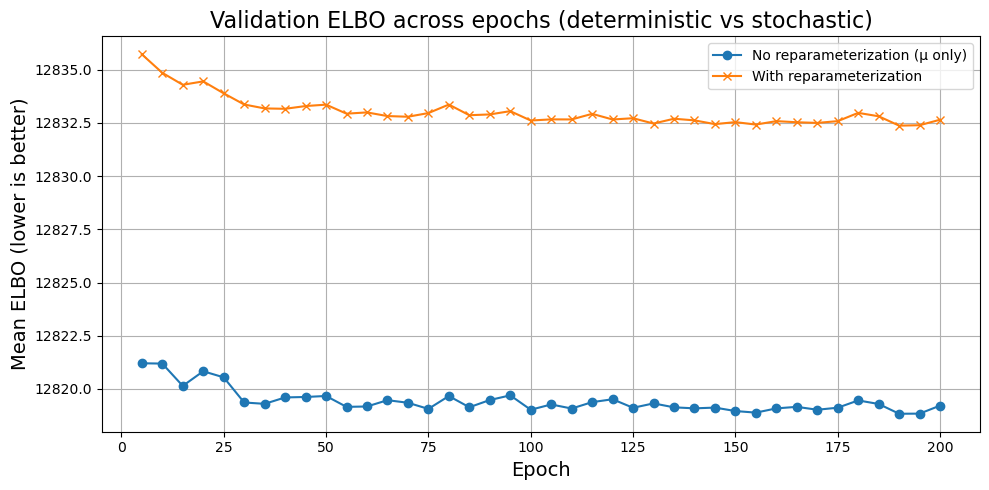

In [ ]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(epochs_large, elbos_deterministic_large, label="No reparameterization (μ only)", marker="o")
plt.plot(epochs_large, elbos_reparam_large, label="With reparameterization", marker="x")
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Mean ELBO (lower is better)", fontsize=14)
plt.title("Validation ELBO across epochs (deterministic vs stochastic)", fontsize=16)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from src.data_loading_well import load_data_by_well

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_dir = "../experiments/models/Runs40/plus_64"
checkpoint_files = sorted([f for f in os.listdir(checkpoint_dir) if f.endswith(".pth")],
                          key=lambda x: int(x.split("_")[1].split(".")[0]))  # e.g., "epoch_25.pth"

model = load_model_and_cfg(os.path.join(checkpoint_dir, checkpoint_files[0]))
cfg = model.cfg
model.to(device)

test_loader = load_data_by_well(cfg, split="test")  # Assuming you have a function to load the test data

def compute_elbos(model, loader, reparam: bool):
    model.eval()
    model.to(device)
    elbo_list = []
    with torch.no_grad():
        for x_batch, _ in loader:
            x_batch = x_batch.to(device)
            mu, logvar = model.encode(x_batch)
            z = model.reparameterize(mu, logvar) if reparam else mu
            recon = model.decode(z)

            recon_loss = 0.5 * ((recon - x_batch) ** 2).view(x_batch.size(0), -1).sum(dim=1)
            D = x_batch[0].numel()
            const = 0.5 * D * np.log(2 * np.pi)
            recon_loss += const

            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
            elbo = (recon_loss + kl_loss).cpu().numpy()
            elbo_list.append(elbo)

    return np.mean(np.concatenate(elbo_list, axis=0))


# Store ELBOs per checkpoint
epochs_plus = []
elbos_reparam_plus = []
elbos_deterministic_plus = []

for file in tqdm(checkpoint_files, desc="Evaluating checkpoints"):
    epoch = int(file.split("_")[1].split(".")[0])
    model = load_model_and_cfg(os.path.join(checkpoint_dir, file))
    model.to(device)

    elbo_det = compute_elbos(model, test_loader, reparam=False)
    elbo_stoch = compute_elbos(model, test_loader, reparam=True)

    epochs_plus.append(epoch)
    elbos_deterministic_plus.append(elbo_det)
    elbos_reparam_plus.append(elbo_stoch)

Total wells Train: 770, Val: 96, Test: 96
Total images in test: 46458 (9.66% of total)


Evaluating checkpoints: 100%|██████████| 40/40 [10:22<00:00, 15.57s/it]


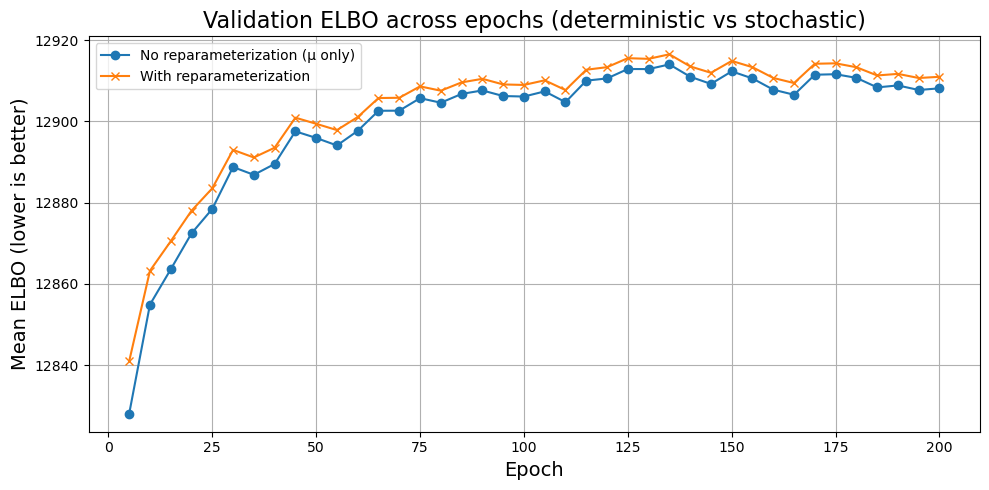

In [20]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(epochs_plus, elbos_deterministic_plus, label="No reparameterization (μ only)", marker="o")
plt.plot(epochs_plus, elbos_reparam_plus, label="With reparameterization", marker="x")
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Mean ELBO (lower is better)", fontsize=14)
plt.title("Validation ELBO across epochs (deterministic vs stochastic)", fontsize=16)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()